In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

# Yeh code aap ko aap ki file ka 100% exact path dhoond kar dikhaye ga
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            print("--- AAP KA EXACT PATH NEECHE HE ---")
            print(os.path.join(root, file))
            print("-----------------------------------")

--- AAP KA EXACT PATH NEECHE HE ---
/kaggle/input/datasets/muhammadumer7804/new-dataset/telecom_customer_churn_feature_engineering.csv
-----------------------------------


In [2]:
import pandas as pd

# Jo path upar se mila, usay yahan paste kar den
df = pd.read_csv('/kaggle/input/datasets/muhammadumer7804/new-dataset/telecom_customer_churn_feature_engineering.csv')

# Check karne ke liye
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


In [3]:
df.info

<bound method DataFrame.info of       customer_id signup_date  age  gender        city education_level  \
0           10001  2019-01-01   65    Male      Multan        Bachelor   
1           10002  2019-01-02   22  Female    Peshawar          Master   
2           10003  2019-01-03   43    Male  Gujranwala       Secondary   
3           10004  2019-01-04   21    Male      Lahore       Secondary   
4           10005  2019-01-05   37  Female   Hyderabad         Primary   
...           ...         ...  ...     ...         ...             ...   
1195        11196  2022-04-10   48    Male  Gujranwala          Master   
1196        11197  2022-04-11   54    Male      Lahore        Bachelor   
1197        11198  2022-04-12   34    Male      Quetta         Primary   
1198        11199  2022-04-13   20    Male      Multan       Secondary   
1199        11200  2022-04-14   28    Male      Quetta        Bachelor   

     employment_status  monthly_income  monthly_bill  internet_usage_gb  \
0   

In [4]:
df.tail()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
1195,11196,2022-04-10,48,Male,Gujranwala,Master,Employed,8193.0,10223.0,5.8,334.0,6-Month,1,Coverage is poor in my location,1
1196,11197,2022-04-11,54,Male,Lahore,Bachelor,Student,32480.0,3320.0,9.9,47.0,Monthly,3,Too expensive compared to competitors,1
1197,11198,2022-04-12,34,Male,Quetta,Primary,Student,42000.0,8147.0,33.0,96.0,12-Month,1,Too expensive compared to competitors,0
1198,11199,2022-04-13,20,Male,Multan,Secondary,Employed,80554.0,8427.0,14.4,157.0,Monthly,1,Service is unreliable during peak hours,0
1199,11200,2022-04-14,28,Male,Quetta,Bachelor,Employed,49647.0,4074.0,16.0,126.0,12-Month,1,Service is unreliable during peak hours,0


In [6]:
df.shape

(1200, 15)

In [7]:
# Date se Year, Month, aur Day of Week (DOW) ke naye columns nikalna
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month
df["signup_dow"] = df["signup_date"].dt.dayofweek

AttributeError: Can only use .dt accessor with datetimelike values

In [8]:
# Naye date features ko check karna
df[["signup_date", "signup_year", "signup_month", "signup_dow"]].head()

KeyError: "['signup_year', 'signup_month', 'signup_dow'] not in index"

In [9]:
df["bill_to_income_ratio"] = df["monthly_bill"] / df["monthly_income"]

# Verification check
df[["monthly_bill", "monthly_income", "bill_to_income_ratio"]].head()

,monthly_bill,monthly_income,bill_to_income_ratio
0,10049.0,57643.0,0.174332
1,2752.0,18207.0,0.151151
2,3155.0,13075.0,0.241300
3,5859.0,38890.0,0.150656
4,5106.0,17475.0,0.292189


In [10]:
# --- 3. Interaction Feature ---
# Do columns ko multiply kar ke naya feature banana (Tickets * Bill = Zyada gussa/frustration)
df["support_bill_interaction"] = df["support_tickets"] * df["monthly_bill"]

# Verification check
df[["support_tickets", "monthly_bill", "support_bill_interaction"]].head()

,support_tickets,monthly_bill,support_bill_interaction
0,1,10049.0,10049.0
1,2,2752.0,5504.0
2,0,3155.0,0.0
3,2,5859.0,11718.0
4,0,5106.0,0.0


In [11]:
# --- 4. Text Length Feature ---
# Customer feedback ke text ki length (chars count) ka naya column banana
df["feedback_length"] = df["customer_feedback"].str.len()

# Verification check
df[["customer_feedback", "feedback_length"]].head()

,customer_feedback,feedback_length
0,Coverage is poor in my location,31
1,Billing issues occurred multiple times,38
2,Billing issues occurred multiple times,38
3,Customer support was helpful,28
4,Coverage is poor in my location,31


In [13]:
# --- 5. Keyword Flag Feature ---
# Specific negative words ko dhoond kar 1 ya 0 ka flag (Binary feature) lagana
df["complaint_flag"] = df["customer_feedback"].str.contains(
    "slow|poor|expensive|unreliable|drops",
    case=False
).astype(int)

In [14]:
# Verification check
df[["customer_feedback", "complaint_flag"]].head()

,customer_feedback,complaint_flag
0,Coverage is poor in my location,1
1,Billing issues occurred multiple times,0
2,Billing issues occurred multiple times,0
3,Customer support was helpful,0
4,Coverage is poor in my location,1


In [15]:
# --- 6. Final Feature Review ---
# Tamam naye banaye gaye features ka aik sath preview dekhna
df[[
    "signup_month",
    "bill_to_income_ratio",
    "support_bill_interaction",
    "feedback_length",
    "complaint_flag"
]].head()

KeyError: "['signup_month'] not in index"

In [16]:
import pandas as pd
import numpy as np
df=pd.DataFrame({
    "sales": [100,200,150,300,5000,700,3000,1500,400,600] # 5000 in an outleir
})
print(df.describe())

             sales
count    10.000000
mean   1195.000000
std    1603.546417
min     100.000000
25%     225.000000
50%     500.000000
75%    1300.000000
max    5000.000000


<function matplotlib.pyplot.show(close=None, block=None)>

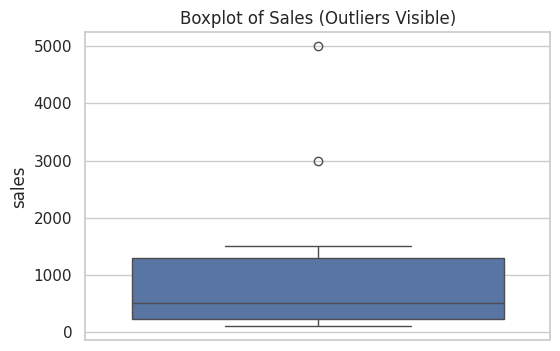

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(y=df["sales"])
plt.title("Boxplot of Sales (Outliers Visible)")
plt.show